In [2]:
import pennylane as qml
import matplotlib.pyplot as plt 

from pennylane import numpy as pnp

# The max-XORSAT problem

In [3]:
plt.style.use("pennylane.drawer.plot")

In [4]:
B = pnp.array([[1, 0, 0, 0], [1, 1, 0, 0], [0, 1, 1, 0], [0, 0, 1, 1], [0, 0, 0, 1]])
v = pnp.array([1, 0, 1, 0, 1])
m, n = B.shape
B_T = B.T
n_samples = 100

In [5]:
def objective_function(x):
    f = 0
    for i in range(m):
        f += (-1) ** (v[i] + B[i, :] @ x)
    return f

In [6]:
samples = pnp.random.randint(0, 2, size=(n_samples, n))
f_x_array_random = [objective_function(sample) for sample in samples]

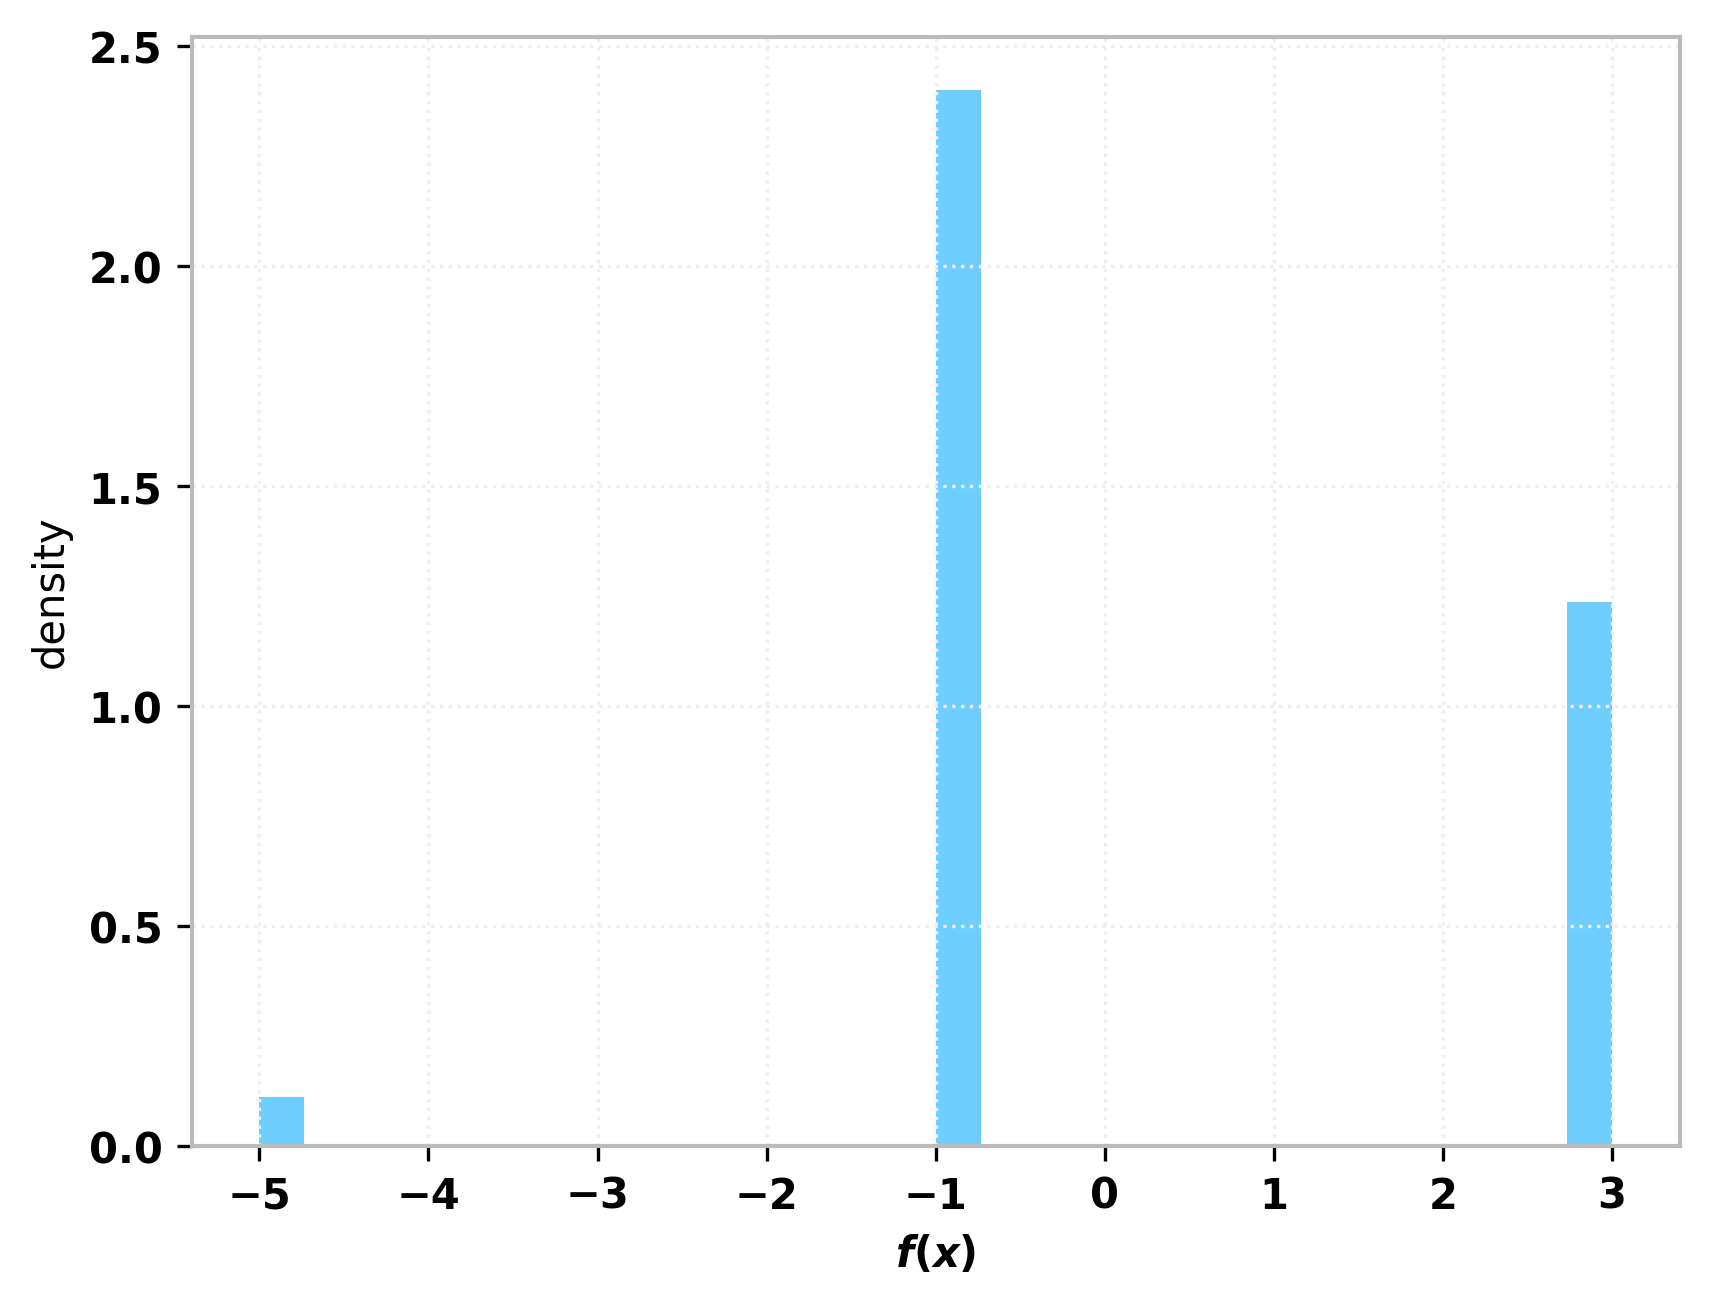

In [7]:
plt.hist(f_x_array_random, bins=30, density=True)
plt.xlabel(r"$f(x)$")
plt.ylabel("density")
plt.show()

# The DQI Algorithm

In [19]:
p = 2 # Field size
r = 1 # Number of inputs yielding f_i=1
d = (p - 2 * r) / pnp.sqrt(r * (p - r))
l = 2 # Polynomial degree

In [20]:
num_weight_qubits = int(pnp.ceil(pnp.log2(l + 1)))
weight_register = range(num_weight_qubits)
m_register = range(num_weight_qubits, m + num_weight_qubits)
n_register = range(m + num_weight_qubits, n + m + num_weight_qubits)

In [21]:
def w_k_optimal(m, l):
    """
    The optimal weights are the components of a principal vector of (l + 1) x (l + 1) matrix.
    """
    diag_main = pnp.diag(pnp.arange(l + 1) * d)
    diag_sup = pnp.diag(pnp.sqrt(pnp.arange(1, l + 1) * (m - pnp.arange(1, l + 1) + 1)), 1)
    A = diag_main + diag_sup + pnp.transpose(diag_sup) # Building A
    _, eigenvectors = pnp.linalg.eigh(A)
    return eigenvectors[:, -1] # Principal eigenvector

In [22]:
w_k = w_k_optimal(m, l)
print("The optimal values are:", w_k)

The optimal values are: [0.43852901 0.70710678 0.5547002 ]


In [23]:
def embed_weights(w_k, weight_register):
    return qml.StatePrep(w_k, wires=weight_register, pad_with=0)

In [24]:
from pprint import pprint

def format_state_vector(state_vector, tol: float=1e-6):
    num_qubits = int(pnp.log2(len(state_vector)))
    state_dict = {}

    for i, amplitude in enumerate(state_vector):
        if pnp.abs(amplitude) > tol:
            bit_string = format(i, f"{num_qubits}b")
            state_dict[bit_string] = complex(amplitude)

    return state_dict

In [25]:
def SCS(m: int, k: int):
    m_angle = m
    m = m + num_weight_qubits - 1
    qml.CNOT(wires=[m - 1, m])
    qml.CRY(2 * pnp.arccos(pnp.sqrt(1 / m_angle)), wires=[m, m - 1])
    qml.CNOT(wires=[m - 1, m])
    # k-1 three-qubit gates
    for l in range(2, k + 1):
        qml.CNOT(wires=[m - l, m])
        qml.ctrl(qml.RY, (m, m - l + 1))(2 * pnp.arccos(pnp.sqrt(l / m_angle)), wires=m - l)
        qml.CNOT(wires=[m - l, m])

def prepare_dicke_state(m, k):
    """Prepares a Dicke state with m qubits and k excitations in a inductive form."""

    # Prepares input state
    for wire_idx in range(m - k + num_weight_qubits, m + num_weight_qubits):
        qml.X(wires=wire_idx)

    # Applies the SCS unitaries
    for i in reversed(range(k + 1, m + 1)):
        SCS(i, k)
    for i in reversed(range(2, k + 1)):
        SCS(i, i - 1)

dev = qml.device("default.qubit")

@qml.qnode(dev)
def weight_error_prep(m: int, n: int, i: int):

    # Prepare weight state
    embed_weights(w_k, weight_register)
    
    # Prepare Dicke states conditioned on 
    qml.ctrl(prepare_dicke_state, weight_register, control_values=(0, 1))(m, k=1)
    qml.ctrl(prepare_dicke_state, weight_register, control_values=(1, 0))(m, k=2)

    return qml.state()

In [26]:
raw_state_vector = weight_error_prep(m, n, l)
formatted_state = format_state_vector(raw_state_vector)
pprint(formatted_state)

{'      0': (0.4385290096535146+0j),
 ' 100001': (0.31622776601683805+0j),
 ' 100010': (0.3162277660168379+0j),
 ' 100100': (0.31622776601683794+0j),
 ' 101000': (0.316227766016838+0j),
 ' 110000': (0.31622776601683794+0j),
 '1000011': (0.17541160386140583+0j),
 '1000101': (0.1754116038614059+0j),
 '1000110': (0.1754116038614059+0j),
 '1001001': (0.17541160386140592+0j),
 '1001010': (0.17541160386140592+0j),
 '1001100': (0.17541160386140586+0j),
 '1010001': (0.1754116038614059+0j),
 '1010010': (0.1754116038614059+0j),
 '1010100': (0.17541160386140583+0j),
 '1011000': (0.1754116038614059+0j)}


In [27]:
from itertools import combinations
from math import comb


def generate_bit_strings(length, hamming_weight):
    """Generates all bit strings of a given length and Hamming weight."""
    one_positions = combinations(range(length), hamming_weight)

    results = []
    for positions in one_positions:
        # Create a new list of zeros
        bit_string = pnp.zeros(length, dtype=int)
        # Place 1s at the specified positions
        bit_string[pnp.array(positions)] = 1
        results.append(bit_string.tolist())

    return results


def uncompute_weight(m, k):
    """Uncomputes weight register."""
    bit_strings_dicke = list(generate_bit_strings(m, k))
    binary_string_weight = bin(k)[2:].zfill(num_weight_qubits)

    for i in range(comb(m, k)):
        for j in range(len(binary_string_weight)):
            bit = int(binary_string_weight[j])
            if bit == 1:
                qml.ctrl(
                    qml.X,
                    m_register,
                    control_values=bit_strings_dicke[i]
                )(weight_register[j])

In [28]:
def phase_Z(v):
    """Imparts a phase (-1)^{vy}."""
    for i in range(len(v)):
        qml.cond(v[i],qml.Z)(wires=i + num_weight_qubits)


@qml.qnode(dev)
def encode_v(m, n, l):
    """Quantum circuit uncomputing weight register and encoding vector of constraints."""

    # Load the previous state
    qml.StatePrep(raw_state_vector, wires=range(0, m + num_weight_qubits))

    # Uncompute weight register
    uncompute_weight(m, k=1)
    uncompute_weight(m, k=2)

    # Impart phase
    phase_Z(v)

    return qml.state()


raw_state_vector = encode_v(m, n, l)
formatted_state = format_state_vector(raw_state_vector)
pprint(formatted_state)

{'      0': (0.4385290096535146+0j),
 '      1': (-0.31622776601683805+0j),
 '     10': (0.3162277660168379+0j),
 '     11': (-0.17541160386140583+0j),
 '    100': (-0.31622776601683794+0j),
 '    101': (0.1754116038614059-0j),
 '    110': (-0.1754116038614059+0j),
 '   1000': (0.316227766016838+0j),
 '   1001': (-0.17541160386140592+0j),
 '   1010': (0.17541160386140592+0j),
 '   1100': (-0.17541160386140586+0j),
 '  10000': (-0.31622776601683794+0j),
 '  10001': (0.1754116038614059-0j),
 '  10010': (-0.1754116038614059+0j),
 '  10100': (0.17541160386140583-0j),
 '  11000': (-0.1754116038614059+0j)}


In [29]:
from functools import partial


def B_T_multiplication(B_T, n_register):
    """Computes B^T y into the syndrome register."""
    for row_index, row in enumerate(B_T):
        for col_index, element in enumerate(row):
            if element == 1:
                qml.CNOT(wires=[m_register[col_index], n_register[row_index]])


@qml.qnode(dev)
def syndrome_prep(m, n, l):
    """Quantum circuit preparing syndrome register."""

    # Load the previous state
    qml.StatePrep(raw_state_vector, wires=range(0, m + num_weight_qubits))

    # Compute s = B^T y into the syndrome register
    B_T_multiplication(B_T, n_register)

    return qml.state()


raw_state_vector = syndrome_prep(m, n, l)
formatted_state = format_state_vector(raw_state_vector)
pprint(formatted_state)

{'          0': (0.4385290096535146+0j),
 '      10001': (-0.31622776601683805+0j),
 '     100011': (0.3162277660168379+0j),
 '     110010': (-0.17541160386140583+0j),
 '    1000110': (-0.31622776601683794+0j),
 '    1010111': (0.1754116038614059-0j),
 '    1100101': (-0.1754116038614059+0j),
 '   10001100': (0.316227766016838+0j),
 '   10011101': (-0.17541160386140592+0j),
 '   10101111': (0.17541160386140592+0j),
 '   11001010': (-0.17541160386140586+0j),
 '  100001000': (-0.31622776601683794+0j),
 '  100011001': (0.1754116038614059-0j),
 '  100101011': (-0.1754116038614059+0j),
 '  101001110': (0.17541160386140583-0j),
 '  110000100': (-0.1754116038614059+0j)}


In [30]:
def syndrome_LUT(parity_check_matrix_T):
    """Generates the Lookup table given a parity-check matrix."""
    num_data_qubits = parity_check_matrix_T.shape[1]
    syndrome_dict = {}

    for i in range(2**num_data_qubits):
        error_bitstring = format(i, f"0{num_data_qubits}b")
        error_vector = pnp.array([int(bit) for bit in error_bitstring])

        syndrome_vector = pnp.dot(parity_check_matrix_T, error_vector) % 2
        syndrome_bitstring = "".join(map(str, syndrome_vector))

        if syndrome_bitstring not in syndrome_dict:
            syndrome_dict[syndrome_bitstring] = error_bitstring
        else:
            existing_error = syndrome_dict[syndrome_bitstring]
            if pnp.sum(error_vector) < pnp.sum(pnp.array([int(bit) for bit in existing_error])):
                syndrome_dict[syndrome_bitstring] = error_bitstring

    # Convert the dictionary to the desired list-of-lists format
    lookup_matrix = []
    for syndrome_str, error_str in syndrome_dict.items():
        syndrome_list = [int(bit) for bit in syndrome_str]
        error_list = [int(bit) for bit in error_str]
        lookup_matrix.append([syndrome_list, error_list])

    # Sort the matrix for a consistent output (e.g., by syndrome)
    lookup_matrix.sort(key=lambda x: int("".join(map(str, x[0])), 2))

    return lookup_matrix


# Generate the lookup table
decoding_table = syndrome_LUT(B_T)

@partial(qml.set_shots, shots=n_samples)
@qml.qnode(dev)
def decoding(m, n, l):
    """Quantum circuit decoding and uncomputing error register"""

    # Load the previous state
    qml.StatePrep(raw_state_vector, wires=range(0, m + n + num_weight_qubits))

    # Uncompute syndrome register using a Lookup table
    for syndrome, error in decoding_table:
        for i in range(len(error)):
            if error[i] == 1:
                qml.ctrl(qml.X, n_register, control_values=syndrome)(m_register[i])

    return qml.counts()


pprint(decoding(m, n, l))

{np.str_('00000000000'): np.int64(28),
 np.str_('00000000001'): np.int64(12),
 np.str_('00000000011'): np.int64(8),
 np.str_('00000000100'): np.int64(5),
 np.str_('00000000101'): np.int64(5),
 np.str_('00000000110'): np.int64(7),
 np.str_('00000000111'): np.int64(2),
 np.str_('00000001000'): np.int64(7),
 np.str_('00000001001'): np.int64(2),
 np.str_('00000001010'): np.int64(5),
 np.str_('00000001011'): np.int64(1),
 np.str_('00000001100'): np.int64(6),
 np.str_('00000001101'): np.int64(5),
 np.str_('00000001110'): np.int64(3),
 np.str_('00000001111'): np.int64(4)}


In [31]:
@partial(qml.set_shots, shots=n_samples)
@qml.qnode(dev)
def DQI(m, n, l):
    """Quantum circuit implementing the DQI algorithm to solve max-XORSAT."""

    # Prepare weight register
    embed_weights(w_k,weight_register)

    # Prepare Dicke states conditioned on k values
    qml.ctrl(prepare_dicke_state, weight_register, control_values=(0,1))(m, k=1)
    qml.ctrl(prepare_dicke_state, weight_register, control_values=(1,0))(m, k=2)

    # Uncompute weight register
    uncompute_weight(m, k=1)
    uncompute_weight(m, k=2)

    # Impart phase
    phase_Z(v)

    # Compute s = B^T y into the syndrome register
    B_T_multiplication(B_T, n_register)

    # Uncompute syndrome register using a Lookup table
    for row in decoding_table:
        syndrome, error = row
        for i in range(len(error)):
            if error[i] == 1:
                qml.ctrl(qml.X, n_register, control_values=syndrome)(m_register[i])

    # Apply Hadamard transform
    for wire in n_register:
        qml.Hadamard(wire)

    return qml.counts(wires=n_register)

{np.str_('0011'): np.int64(16),
 np.str_('0100'): np.int64(1),
 np.str_('0110'): np.int64(4),
 np.str_('1011'): np.int64(18),
 np.str_('1100'): np.int64(19),
 np.str_('1101'): np.int64(21),
 np.str_('1111'): np.int64(21)}


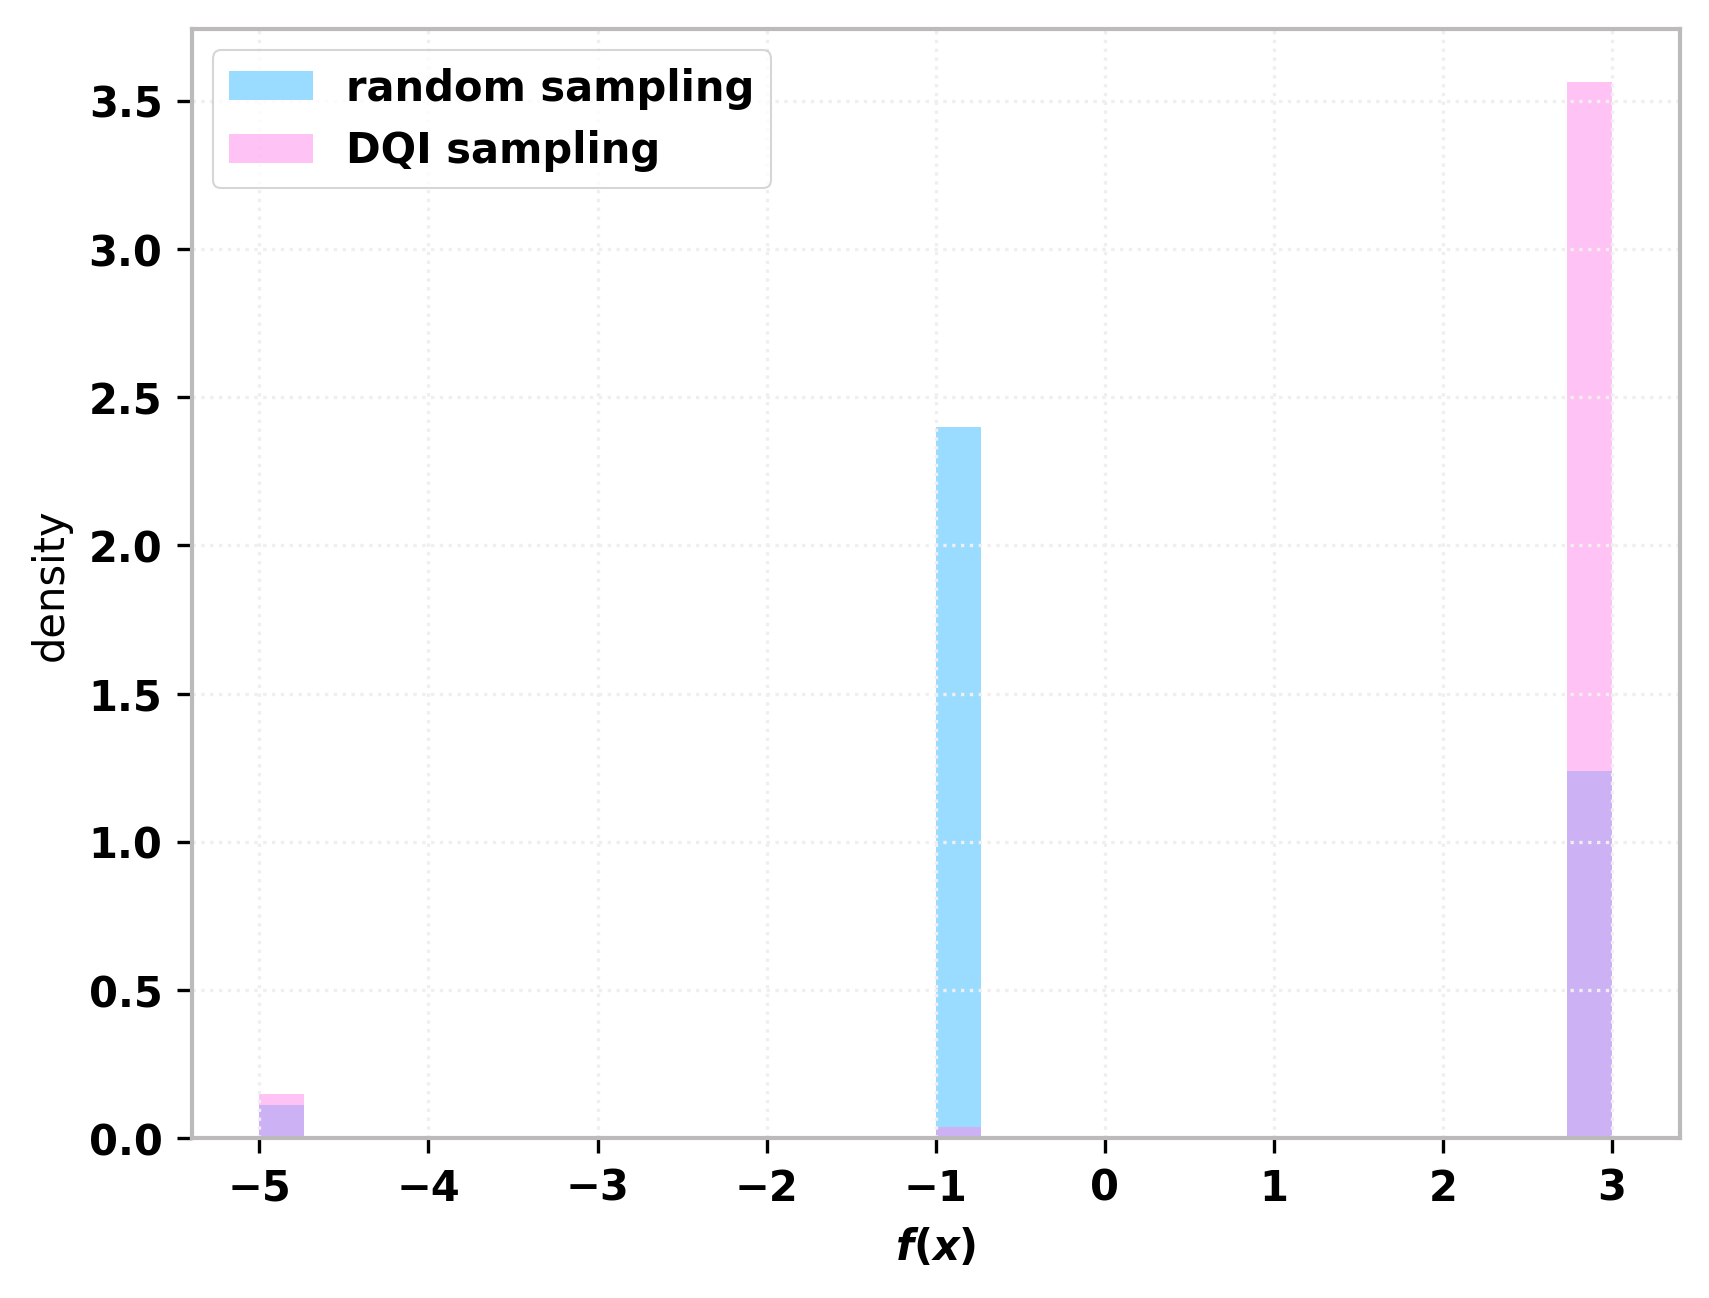

In [32]:
results = DQI(m, n, l)
all_bit_lists = []
for string, samples in results.items():
    integer_list = [int(bit) for bit in string]
    for _ in range(samples):
        all_bit_lists.append(integer_list)

DQI_array = pnp.array(all_bit_lists)  # DQI sample array

f_x_array_DQI = [objective_function(DQI_array[i]) for i in range(n_samples)]

pprint(results)
plt.hist(f_x_array_random, bins=30, alpha=0.7, density=True, label="random sampling")
plt.hist(f_x_array_DQI, bins=30, alpha=0.5, density=True, label="DQI sampling")
plt.xlabel(r"$f(x)$")
plt.ylabel("density")
plt.legend(prop={"size": 10})
plt.show()